# K-Means Clustering

K-Means is an **unsupervised clustering algorithm** that divides data into **K clusters** based on similarity/distance.


## Step-by-Step

### 1. Choose K
Choose the number of clusters, **K**.

Example:
```text
K = 3
```

This means we want 3 clusters.

### 2. Randomly Initialize K Centroids
Randomly place **K centroids** in the feature space.

A **centroid** is the representative/center point of a cluster.

```text
C1     C2     C3
```

At this stage, the centroids are only initial guesses.

### 3. Calculate Distance
For **every data point**, calculate its distance from **each centroid**.

Common distance measures include:

- Euclidean distance
- Manhattan distance

The point is assigned to the centroid with the **minimum distance**.

```text
Point → nearest centroid → cluster
```

### 4. Form the Clusters
After assigning all points to their nearest centroids, the data is divided into **K clusters**.

Each cluster contains the points closest to its centroid.

### 5. Update the Centroids
Now calculate a **new centroid for each cluster**.

The new centroid is the **mean of all data points belonging to that cluster**.

```text
New centroid = Mean of all points in the cluster
```

So the centroid moves from its initial random position toward the actual center of its assigned points.

### 6. Reassign the Points
Using the **new centroids**, calculate the distance of every point again.

Assign each point to its **nearest centroid**.

The cluster membership may change because the centroids have moved.

### 7. Update the Centroids Again
For the newly formed clusters:

```text
New centroid = Mean of points in that cluster
```

The centroids move again.

### 8. Repeat
Repeat these two operations:

```text
Assign points → Update centroids
       ↑              ↓
       └──── repeat ──┘
```

The process continues until the clusters/centroids become stable.

### 9. Convergence
K-Means is considered to have **converged** when the centroids stop moving significantly or the cluster assignments stop changing.

The final result is **K clusters**, each represented by its centroid.

## The Core Cycle

```text
Random Centroids
       ↓
Calculate Distances
       ↓
Assign Points to Nearest Centroid
       ↓
Form Clusters
       ↓
Calculate Mean of Each Cluster
       ↓
Update Centroids
       ↓
Reassign Points
       ↓
Update Again
       ↓
Repeat Until Convergence
```

## Key Terms

| Term | Meaning |
|---|---|
| **K** | Number of clusters |
| **Centroid** | Center/representative of a cluster |
| **Distance** | Measures how close a point is to a centroid |
| **Assignment** | Giving each point to its nearest centroid |
| **Update** | Recalculating centroid using the mean |
| **Convergence** | Centroids/assignments become stable |

### One-line intuition

**K-Means repeatedly assigns points to the nearest centroid and then moves each centroid to the mean of its assigned points until the clusters stabilize.**


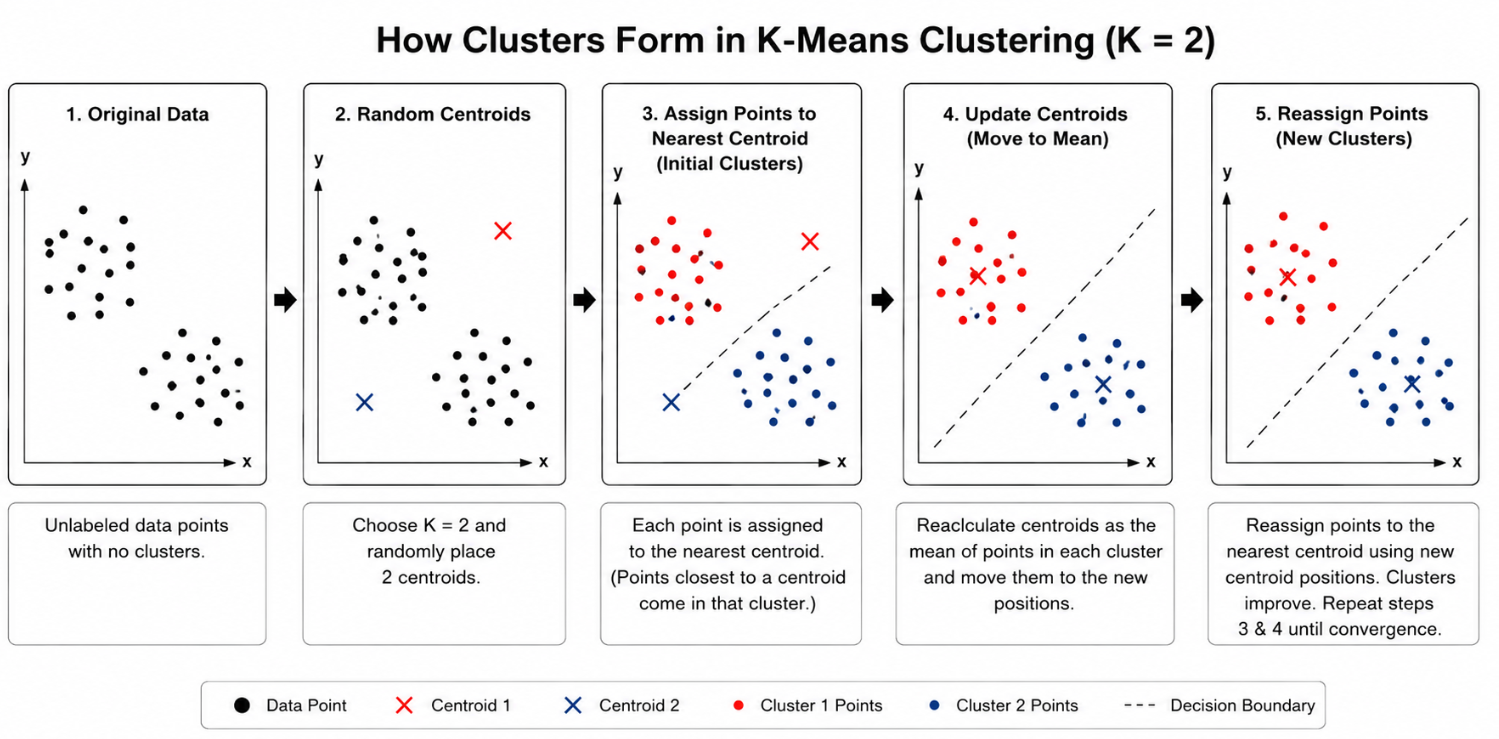

# Elbow Method for Selecting K

The **Elbow Method** is used to choose a suitable value of **K** in K-Means clustering.

## Step 1: Try Different K Values

Run K-Means for several values of K:

```text
K = 1, 2, 3, 4, 5, ...
```

For each K, calculate the **WCSS**.

## Step 2: Calculate WCSS

**WCSS = Within-Cluster Sum of Squares**

It measures how close the data points are to their cluster centroids.

### Formula

```text
              K     n
WCSS =       Σ     Σ (xᵢ - μₖ)²
             k=1   i=1
```

Where:

- **K** = number of clusters
- **n** = number of data points
- **xᵢ** = a data point
- **μₖ** = centroid of cluster k
- **(xᵢ - μₖ)²** = squared distance between the point and its centroid

In simple terms:

```text
Distance → Square the distance → Add for all points
```

For each point, we calculate its distance from its **nearest/current cluster centroid**, square that distance, and sum these values for all points.

## Step 3: Calculate WCSS for Each K

Example:

```text
K = 1 → WCSS = ...
K = 2 → WCSS = ...
K = 3 → WCSS = ...
K = 4 → WCSS = ...
K = 5 → WCSS = ...
```

As K increases, WCSS generally **decreases** because more clusters allow points to be closer to their centroids.

## Step 4: Plot K vs WCSS

- **X-axis:** K (number of clusters)
- **Y-axis:** WCSS

The curve usually drops quickly at first and then starts flattening.

## Step 5: Find the Elbow Point

Choose the K where the curve shows a clear **bend/elbow**.

Before the elbow:
- Increasing K gives a large reduction in WCSS.

After the elbow:
- Increasing K gives only a small improvement.

The elbow is therefore a reasonable choice for **K**.

## Quick Flow

```text
Try different K values
        ↓
Run K-Means
        ↓
Calculate WCSS for each K
        ↓
Plot K vs WCSS
        ↓
Find the elbow point
        ↓
Choose K
```

### Key Idea

**Choose the K where adding more clusters no longer gives a significant reduction in WCSS.**


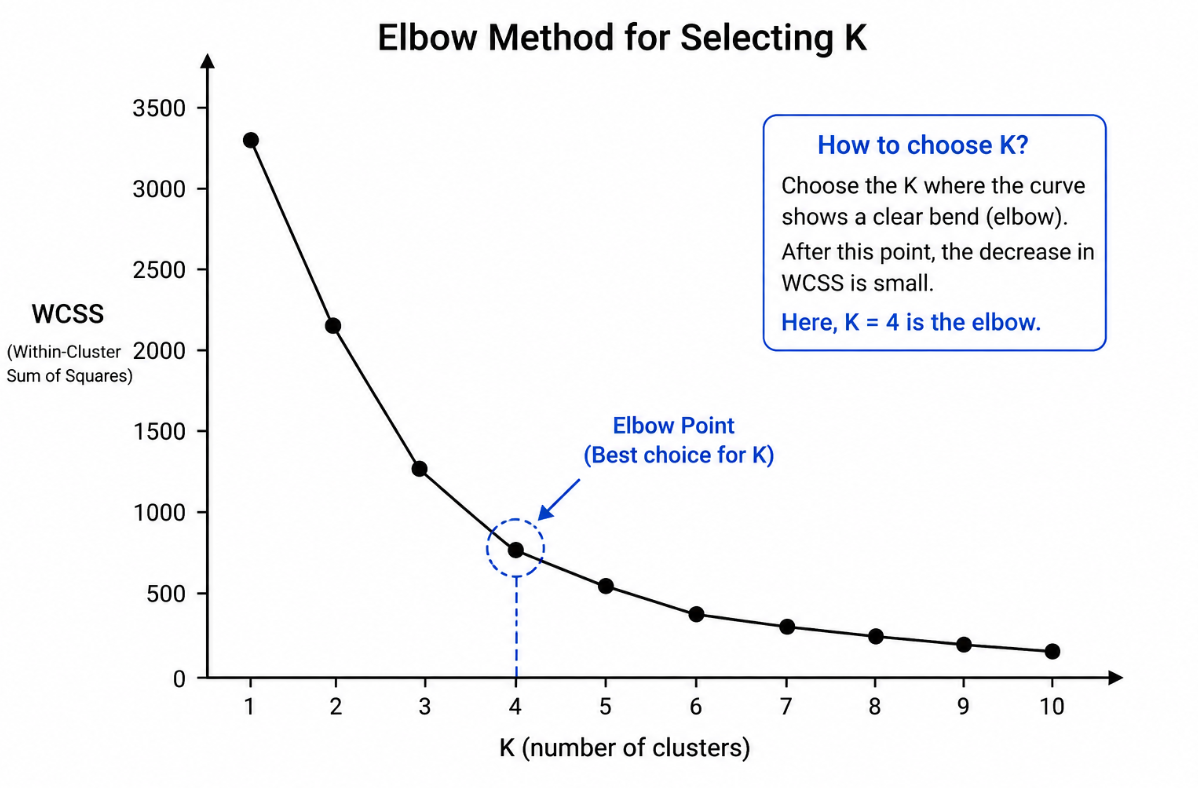

# Silhouette Score for Selecting the Best K

The **Silhouette Score** is an evaluation method used to choose a good value of **K** in K-Means clustering.

The main idea is simple:

> A good clustering should have points **close to their own cluster** and **far from other clusters**.

A higher Silhouette Score means better-defined clusters.

---

## Step 1: Choose a Candidate K

Choose a possible value of K and run K-Means.

For example:

```text
K = 2
```

Then calculate the Silhouette Score for the resulting clusters.

We can repeat this for different K values:

```text
K = 2 → Silhouette Score
K = 3 → Silhouette Score
K = 4 → Silhouette Score
K = 5 → Silhouette Score
```

Then compare the scores.

---

# Step 2: Take One Data Point

Consider one data point **i**.

We evaluate how well this point fits into its current cluster.

For this, we need two values:

```text
a(i) → distance within its own cluster
b(i) → distance to the nearest other cluster
```

---

# Step 3: Calculate a(i)

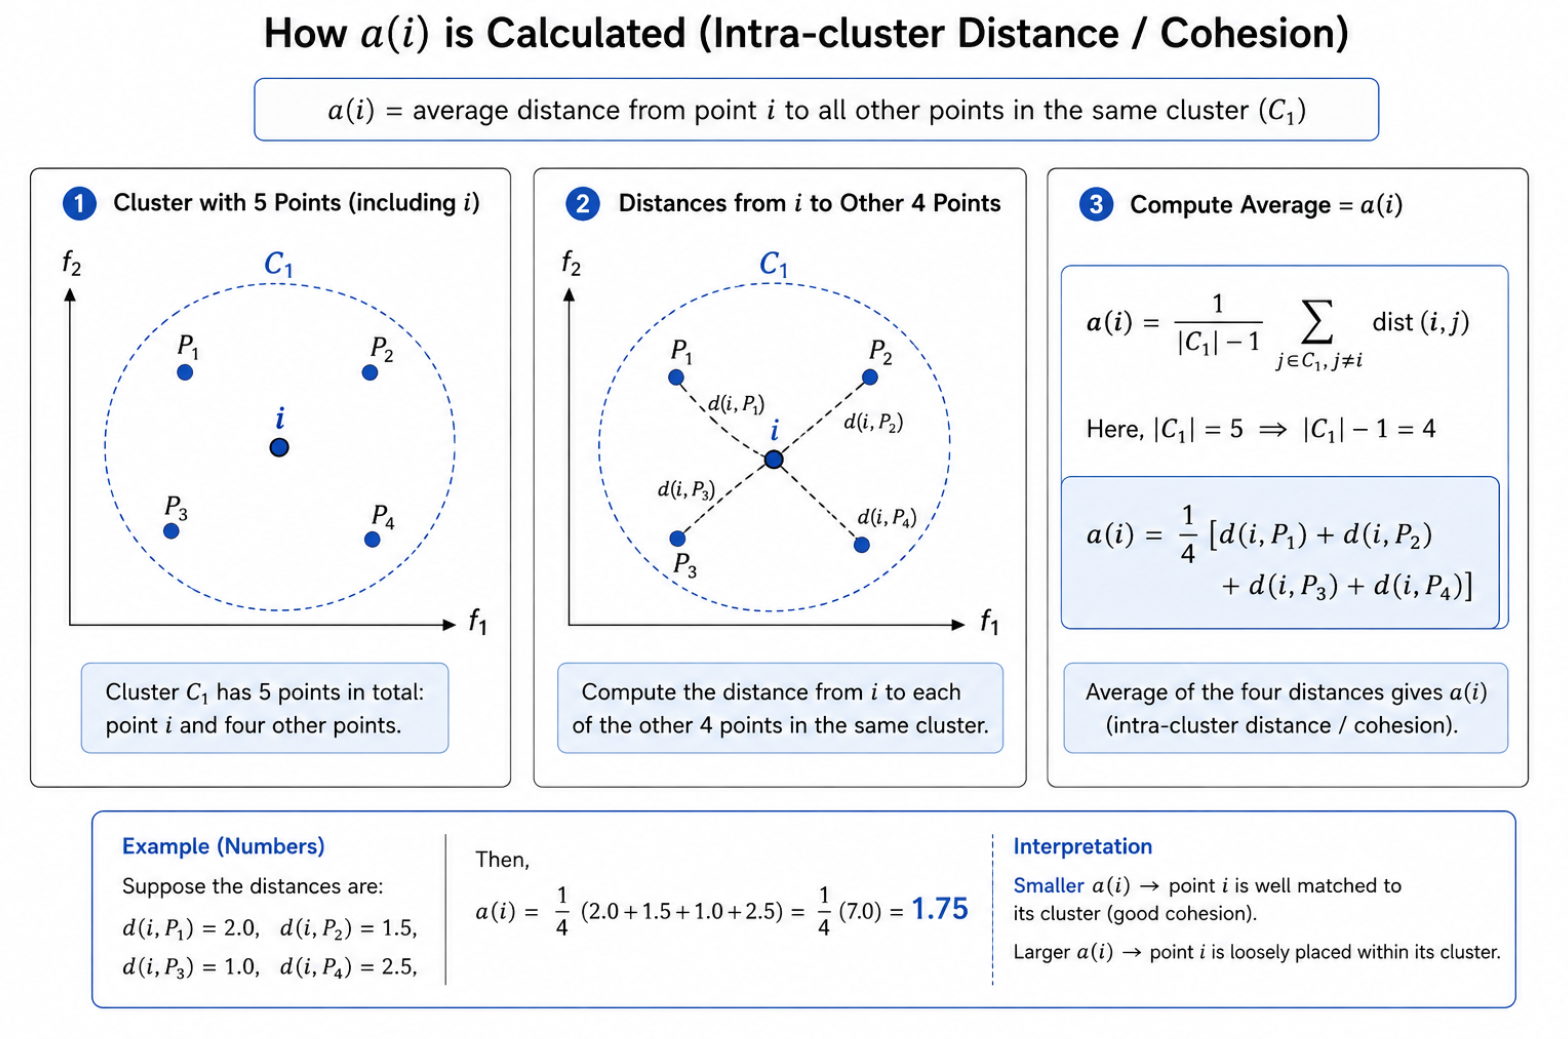

### a(i) = Intra-Cluster Distance

`a(i)` tells us how close point **i** is to the other points in **its own cluster**.

It is the **mean distance** from point `i` to all other points in the same cluster.

### Formula

```text
             1
a(i) = -------------  Σ dist(i, j)
          |Cᵢ| - 1    j ∈ Cᵢ
```

Where:

- `Cᵢ` = cluster containing point `i`
- `|Cᵢ|` = number of points in that cluster
- `dist(i, j)` = distance between points `i` and `j`

### Meaning

```text
Small a(i)
    ↓
Point is close to its own cluster
    ↓
Good cohesion
```

So, **lower a(i) is better**.

---

# Step 4: Calculate b(i)

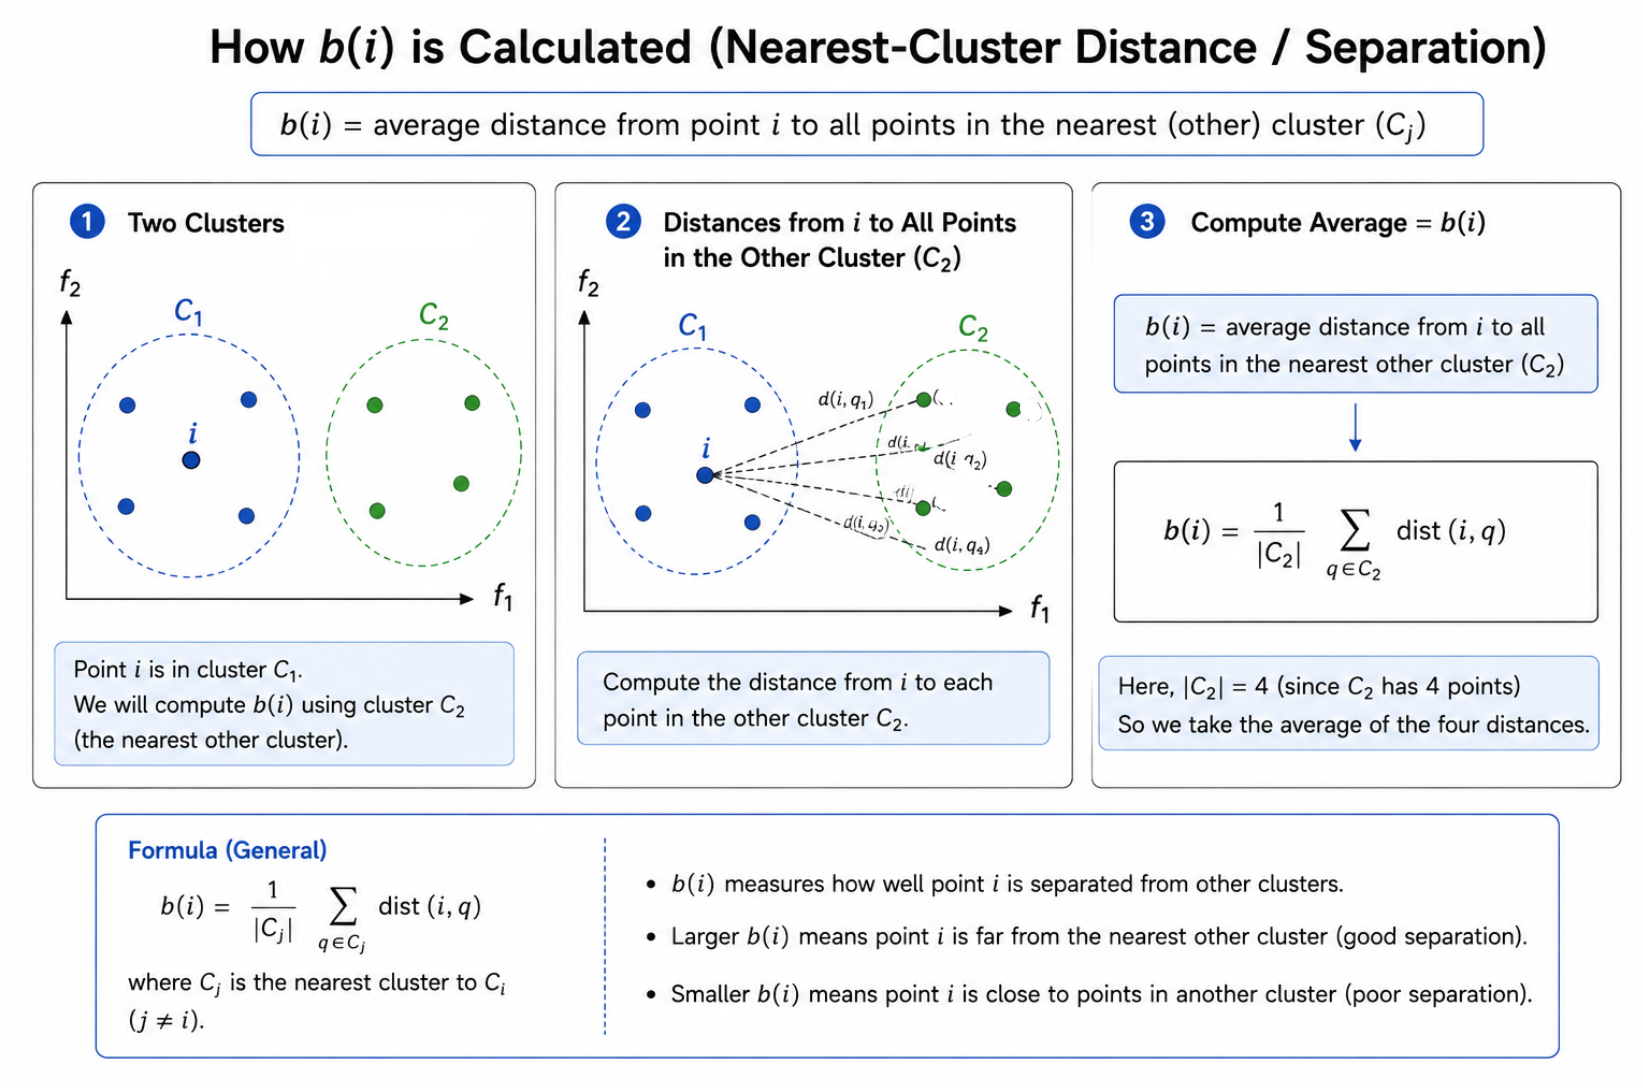

### b(i) = Nearest-Cluster Distance

Now look at the **other clusters**.

For each other cluster, calculate the average distance from point `i` to all points in that cluster.

Then take the **minimum** of those average distances.

### Formula

```text
             1
b(i) = min [ -------  Σ dist(i, j) ]
        j ≠ i   |Cⱼ|   j ∈ Cⱼ
```

In simple words:

```text
Calculate average distance to each other cluster
                    ↓
             Take the minimum
                    ↓
                  b(i)
```

### Meaning

`b(i)` represents how close point `i` is to its **nearest neighboring cluster**.

```text
Large b(i)
    ↓
Point is far from other clusters
    ↓
Good separation
```

So, **higher b(i) is better**.

---

# Step 5: Calculate the Silhouette Value s(i)

Now we have:

```text
a(i) = distance within its own cluster
b(i) = distance to nearest other cluster
```

The Silhouette Value for point `i` is:

```text
             b(i) - a(i)
s(i) = ---------------------------
        max{a(i), b(i)}
```

The Silhouette Value is always in the range:

```text
-1 ≤ s(i) ≤ 1
```

---

# Step 6: Understand the Three Cases

## Case 1: a(i) > b(i)

The point is closer, on average, to another cluster than to its own cluster.

```text
a(i) > b(i)
```

Then:

```text
s(i) < 0
```

### Meaning

**Bad clustering for this point.**

The point may be assigned to the wrong cluster.

---

## Case 2: a(i) < b(i)

The point is closer to its own cluster and farther from the nearest other cluster.

```text
a(i) < b(i)
```

Then:

```text
s(i) > 0
```

### Meaning

**Good clustering for this point.**

The point is well matched to its own cluster and separated from other clusters.

---

## Case 3: a(i) = b(i)

The point is equally close to its own cluster and the nearest other cluster.

```text
a(i) = b(i)
```

Therefore:

```text
s(i) = 0
```

### Meaning

The point is at the **boundary between clusters**.

---

# Step 7: Calculate the Overall Silhouette Score

So far, `s(i)` gives the score for **one point**.

To evaluate the entire clustering, calculate the average Silhouette Value of all `N` points.

### Formula

```text
              N
             Σ s(i)
SS =         i=1
             -------
               N
```

Or:

```text
SS = 1/N × Σ s(i)
```

Where:

- `N` = total number of data points
- `s(i)` = Silhouette Value of point `i`
- `SS` = overall Silhouette Score

---

# Step 8: Repeat for Different K Values

Now calculate the overall Silhouette Score for different values of K.

Example:

```text
K = 2 → SS = 0.51
K = 3 → SS = 0.72
K = 4 → SS = 0.64
K = 5 → SS = 0.58
```

Compare the scores.

### Choose the K with the higher Silhouette Score.

In this example:

```text
K = 3
```

has the highest score, so it would be the preferred K among these choices.

---

# What Is Actually Happening?

For every point, Silhouette Score asks two questions:

### 1. How well does this point fit inside its own cluster?

Measured by:

```text
a(i)
```

Lower is better.

### 2. How far is this point from the nearest other cluster?

Measured by:

```text
b(i)
```

Higher is better.

Then these two values are combined:

```text
a(i)  ← cohesion
  \
   → s(i) → overall clustering quality
  /
b(i)  ← separation
```

So Silhouette Score evaluates both:

- **Cohesion:** points within the same cluster should be close.
- **Separation:** different clusters should be far apart.

---

# Interpreting the Score

```text
s(i) ≈ +1
→ Very good clustering for the point

s(i) ≈ 0
→ Point is near a cluster boundary

s(i) < 0
→ Point may be assigned to the wrong cluster
```

The overall score also lies between:

```text
-1 and +1
```

Generally:

```text
Higher score → Better-defined clustering
Lower score  → Poorer clustering
```

---

# Complete Process

```text
Choose K
   ↓
Run K-Means
   ↓
For each point i
   ↓
Calculate a(i)
(distance to points in own cluster)
   ↓
Calculate b(i)
(average distance to each other cluster,
then take the minimum)
   ↓
Calculate s(i)
   ↓
Repeat for every point
   ↓
Average all s(i)
   ↓
Overall Silhouette Score
   ↓
Repeat for different K values
   ↓
Compare scores
   ↓
Choose K with the highest/best score
```

## Key Formula to Remember

```text
             b(i) - a(i)
s(i) = ---------------------------
        max{a(i), b(i)}
```

### The core idea

**a(i) measures cohesion, b(i) measures separation, and the Silhouette Score combines both to tell us how well the clusters are formed.**


---
---
# Random Initialization Trap and K-Means++

## Random Initialization Trap

In standard K-Means, the initial **K centroids are chosen randomly**.

A poor random initialization can place multiple centroids close to the same natural group while leaving another group without a good centroid.

This can lead to:
- Poor cluster formation
- A poor local solution
- Different results from different initializations

## How K-Means++ Prevents It

**K-Means++** chooses the initial centroids more intelligently instead of choosing all of them randomly.

### Step 1: Choose the First Centroid

Choose the first centroid randomly.

### Step 2: Calculate Distance

For every remaining data point, calculate its distance from the **nearest already-selected centroid**.

```text
Point → nearest centroid
```

### Step 3: Give Higher Probability to Distant Points

The next centroid is selected with probability based on the **squared distance (D²)** from the nearest existing centroid.

```text
Farther from existing centroids
        ↓
Larger D²
        ↓
Higher probability of selection
```

This encourages centroids to spread across different regions of the data.

### Step 4: Repeat

Repeat the distance calculation and centroid selection until **K centroids** have been selected.

```text
1st centroid
      ↓
Calculate nearest distances
      ↓
Select 2nd centroid
      ↓
Calculate nearest distances again
      ↓
Select 3rd centroid
      ↓
...
      ↓
K centroids
```

### Step 5: Run Normal K-Means

After the initial centroids are selected, normal K-Means begins:

```text
K-Means++ initialization
          ↓
Good initial centroids
          ↓
Assign points to nearest centroid
          ↓
Update centroids using the mean
          ↓
Repeat until convergence
```

## Key Difference

| Random Initialization | K-Means++ |
|---|---|
| Centroids are randomly placed | First centroid is random, later ones are distance-based |
| Centroids can start too close | Encourages centroids to spread out |
| Can produce poor initialization | Usually provides a better starting point |
| May lead to a poor local solution | Helps reduce the chance of a poor starting solution |

## Key Idea

**Random K-Means:** random starting centroids can be badly positioned.

**K-Means++:** selects subsequent centroids with higher probability for points that are far from existing centroids, giving K-Means a better starting position.


# Code

In [9]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
import seaborn as sns
from sklearn.datasets import make_blobs

In [10]:
X, y= make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

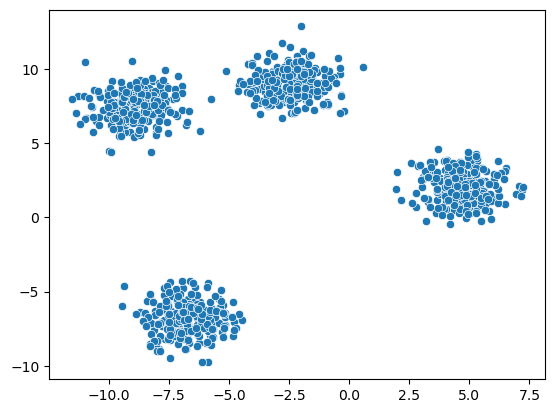

In [11]:
sns.scatterplot(x=X[:,0], y=X[: , 1])

### Scaling
Scaling the data is very important if data is not scaled. we have generated the data using make_blobs so no need to scale it

In [12]:
from sklearn.cluster import KMeans


In [13]:
k=4 # assume

kmeans=KMeans(
    n_clusters=k,
    random_state=42
)

In [14]:
labels = kmeans.fit_predict(X)
# label=cluster no

<Axes: >

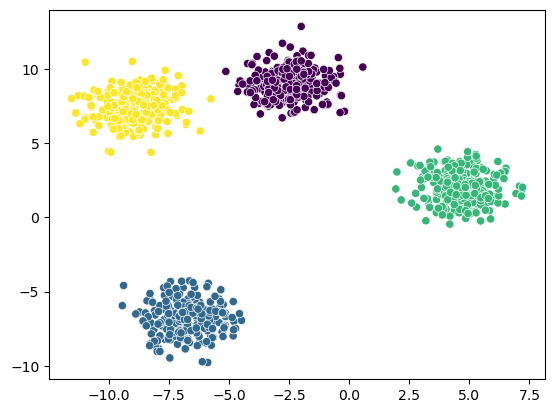

In [15]:
sns.scatterplot(x=X[:,0], y=X[: , 1], c=labels)

### How to choose k value - Elbow method


In [16]:
# manually doing it first
wcss=[]
for k in range(1,21):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_) #append value of wcss 

<Axes: >

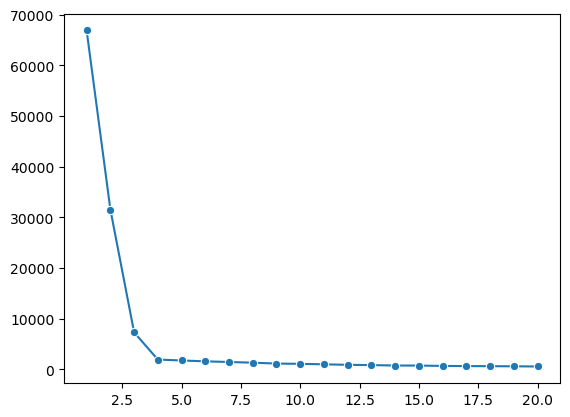

In [17]:
sns.lineplot(x=range(1,21), y=wcss, marker='o')

### kneed Module - automatic method for elbow

In [18]:
!pip install kneed

In [19]:
from kneed import KneeLocator

In [26]:
knee=KneeLocator(range(1,21), wcss, curve="convex", direction="decreasing")

In [27]:
print(f"Optimal k: {knee.knee}")

Optimal k: 4


# Silhouette score

In [22]:
from sklearn.metrics import silhouette_score

In [31]:
ss=[]

# start k form 2 not 1
for k in range(2,21):
    kmeans=KMeans(n_clusters=k)
    labels=kmeans.fit_predict(X)
    score=silhouette_score(X, labels)

    ss.append(score)

<Axes: >

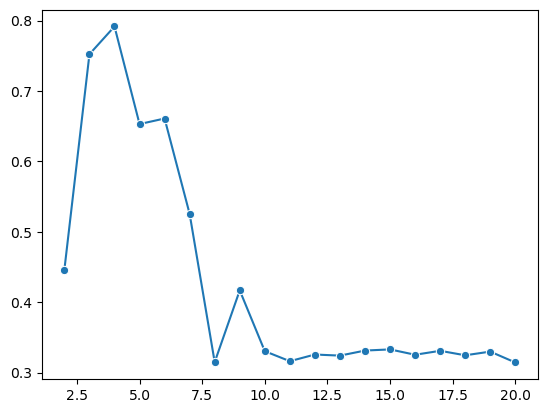

In [32]:
sns.lineplot(x=range(2,21), y=ss, marker='o')

In [33]:
# highest ss on 4 so best k=4